<a href="https://colab.research.google.com/github/watermelonripeness-thesis/Watermelon-Audio-Model/blob/main/preprocess_from_eda_no_undersample_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing Pipeline (Based on Finalized EDA) -- NO UNDERSAMPLING

Builds the train/test feature tables used for model training, using the
exact thump-detection method and feature set validated in the EDA
notebook. Output is CSV only (no audio files are exported here).

**This version skips class balancing entirely** -- the train set keeps
its natural class distribution (whatever the real ripe/unripe split is
after the raw-file train/test split). Use this to compare against the
undersampled version and see how much of the model's performance was
coming from the balancing step itself.

**Order of operations (leakage-safe):**
1. Split RAW FILES into train/test (stratified, seeded) -- before any
   cleaning or feature extraction
2. Detect the thump adaptively in each file (same method as EDA)
3. Extract MFCC + spectral features from that window (see detailed
   explanation of the FFT/MFCC pipeline below)
4. Scale features -- fit on TRAIN only, apply to both
5. ~~Balance classes~~ -- **skipped in this version**; both train and
   test keep their natural, real-world class distribution


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RIPE_DIR = "/content/drive/MyDrive/Watermelon Data/audio/ripe_orig"
UNRIPE_DIR = "/content/drive/MyDrive/Watermelon Data/audio/unripe_orig"
OUT_DIR = "/content/drive/MyDrive/Watermelon Data/z. csv"
os.makedirs(OUT_DIR, exist_ok=True)

SR = 16000
N_MFCC = 13
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Thump-detection config -- IDENTICAL to the finalized EDA notebook, so
# the features here reflect exactly what was validated there.
MIN_SEARCH_TIME = 0.3       # skip the first 0.3s (handling noise) when looking for the peak
PRE_PADDING = 0.02           # 20ms of context before the detected peak
DECAY_THRESHOLD_DB = 20      # cut the window where the signal is 20dB below the peak
MAX_WINDOW = 0.6             # safety cap so a very slow decay doesn't run away

np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
PALETTE = {"ripe": "tab:red", "unripe": "tab:green"}


## Step 0: list files, split RAW FILES first

In [ ]:
def list_audio_files(folder):
    exts = (".wav", ".mp3", ".m4a", ".flac", ".ogg")
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(exts)])

ripe_files = list_audio_files(RIPE_DIR)
unripe_files = list_audio_files(UNRIPE_DIR)
print(f"Ripe: {len(ripe_files)}, Unripe: {len(unripe_files)}")

def split_raw_files(ripe_files, unripe_files, test_size=TEST_SIZE, seed=RANDOM_STATE):
    ripe_train, ripe_test = train_test_split(ripe_files, test_size=test_size, random_state=seed, shuffle=True)
    unripe_train, unripe_test = train_test_split(unripe_files, test_size=test_size, random_state=seed, shuffle=True)
    return ripe_train, ripe_test, unripe_train, unripe_test

ripe_train_f, ripe_test_f, unripe_train_f, unripe_test_f = split_raw_files(ripe_files, unripe_files)
print(f"Train -> ripe: {len(ripe_train_f)}, unripe: {len(unripe_train_f)}")
print(f"Test  -> ripe: {len(ripe_test_f)}, unripe: {len(unripe_test_f)}")

Ripe: 155, Unripe: 339
Train -> ripe: 124, unripe: 271
Test  -> ripe: 31, unripe: 68


### 0.1 Sanity check: raw file counts per split

Quick table + chart so an imbalanced split (or a split that's gone
sideways) is obvious before any audio processing happens.


       ripe  unripe
train   124     271
test     31      68


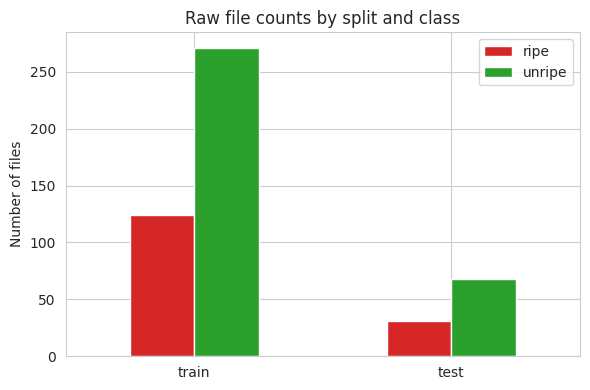

In [ ]:
split_counts = pd.DataFrame({
    "ripe": [len(ripe_train_f), len(ripe_test_f)],
    "unripe": [len(unripe_train_f), len(unripe_test_f)],
}, index=["train", "test"])
print(split_counts)

split_counts.plot(kind="bar", color=[PALETTE["ripe"], PALETTE["unripe"]], figsize=(6, 4))
plt.title("Raw file counts by split and class")
plt.ylabel("Number of files")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 1: Adaptive thump-window detection

IDENTICAL to the finalized EDA notebook: skip the first 0.3s (handling
noise), find the highest-*energy* RMS-envelope frame in the remaining
signal, then take the true amplitude peak within that frame (more
robust to a stray loud transient than a plain global max-amplitude
search). From that peak, cut the window where the frame-wise RMS
envelope (smoothed, to avoid triggering on brief mid-ringing dips)
stays below 20dB from the peak for a sustained period.

In [ ]:
def load_resampled(path, sr=SR):
    y, _ = librosa.load(path, sr=sr)
    return y


def rms_envelope_frames(y, sr, frame_ms=15, hop_ms=5):
    frame_len = max(int(frame_ms / 1000 * sr), 32)
    hop = max(int(hop_ms / 1000 * sr), 1)
    rms = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop)[0]
    return rms, hop


def moving_average(x, w):
    if w <= 1 or len(x) == 0:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")


def find_thump_window(y, sr, min_search_time=MIN_SEARCH_TIME, pre_padding=PRE_PADDING,
                       decay_threshold_db=DECAY_THRESHOLD_DB, max_window=MAX_WINDOW,
                       frame_ms=15, hop_ms=5, smooth_window=5, sustain_ms=30):
    min_search_sample = int(min_search_time * sr)
    search_region = y[min_search_sample:]
    if len(search_region) == 0:
        return y, 0.0, len(y) / sr

    envelope_frame_len = max(int(0.016 * sr), 32)   # ~16ms
    envelope_hop = max(int(0.004 * sr), 1)            # ~4ms
    rms_env = librosa.feature.rms(y=search_region, frame_length=envelope_frame_len,
                                    hop_length=envelope_hop)[0]
    if len(rms_env) == 0:
        peak_idx = np.argmax(np.abs(search_region)) + min_search_sample
    else:
        best_frame = np.argmax(rms_env)
        frame_start = best_frame * envelope_hop
        frame_end = min(frame_start + envelope_frame_len, len(search_region))
        local_peak_offset = np.argmax(np.abs(search_region[frame_start:frame_end]))
        peak_idx = min_search_sample + frame_start + local_peak_offset

    peak_amp = np.abs(y[peak_idx])

    remaining = y[peak_idx:]
    rms, hop = rms_envelope_frames(remaining, sr, frame_ms, hop_ms)

    if len(rms) == 0 or peak_amp == 0:
        end_idx = min(len(y), peak_idx + int(max_window * sr))
    else:
        smoothed = moving_average(rms, smooth_window)
        threshold = peak_amp / (10 ** (decay_threshold_db / 20))
        sustain_frames = max(int(sustain_ms / hop_ms), 1)

        below = smoothed < threshold
        end_frame = None
        run = 0
        for i, b in enumerate(below):
            run = run + 1 if b else 0
            if run >= sustain_frames:
                end_frame = i - sustain_frames + 1
                break
        end_idx = peak_idx + end_frame * hop if end_frame is not None else len(y)
        end_idx = min(end_idx, peak_idx + int(max_window * sr))

    start_idx = max(0, peak_idx - int(pre_padding * sr))
    windowed = y[start_idx:end_idx]
    return windowed, peak_idx / sr, end_idx / sr

## Step 2: Feature Extraction -- How MFCC and FFT Are Used

Every feature extracted here comes from one of two domains: the
**time domain** (computed directly on the waveform's amplitude values)
or the **frequency domain** (computed on the signal's frequency content,
which requires the Fast Fourier Transform). Being explicit about which
is which matters, since it explains what each feature can and can't
tell you:

### Time-domain features (no FFT involved)
- **`rms`** -- root-mean-square amplitude of the windowed signal. A
  direct measure of loudness/energy. Computed purely from waveform
  sample values.
- **`zero_crossing_rate`** -- how often the waveform crosses zero
  amplitude per unit time. A simple time-domain measure loosely related
  to noisiness/pitch, again with no FFT involved.

### Frequency-domain features (FFT-derived, but NOT MFCC)
librosa computes a **Short-Time Fourier Transform (STFT)** internally
for these -- the windowed signal is split into short overlapping
frames, each frame's frequency spectrum is obtained via FFT, and the
following are computed directly from that magnitude spectrum, frame by
frame (then averaged across frames here):
- **`spectral_centroid`** -- the "center of mass" of the spectrum
  (weighted average frequency). Higher = brighter/higher-pitched sound.
- **`spectral_bandwidth`** -- how spread out the spectrum is around
  the centroid.
- **`spectral_rolloff`** -- the frequency below which a specified
  percentage (librosa default 85%) of the spectral energy is contained.

### MFCC (Mel-Frequency Cepstral Coefficients) -- also FFT-derived,
### but with additional processing on top
MFCCs summarize the *shape* of the spectrum rather than reading it
directly. The pipeline, per frame:
1. **FFT** -- get the magnitude spectrum of the frame (same starting
   point as the spectral features above).
2. **Mel filterbank** -- group FFT bins into bands spaced according to
   the Mel scale, which compresses high frequencies more than low ones
   (mimicking human pitch perception).
3. **Log** -- take the log of the energy in each Mel band.
4. **DCT (Discrete Cosine Transform)** -- decorrelate and compress the
   log-Mel-energies into a small number of coefficients. Lower-numbered
   coefficients capture broad/coarse spectral shape; higher-numbered
   ones capture progressively finer spectral detail.

13 coefficients are extracted per frame (`N_MFCC = 13`); both the
**mean** and **standard deviation** of each coefficient across all
frames in the window are kept (`mfcc{i}_mean`, `mfcc{i}_std`) -- the
mean summarizes the average spectral shape, the std summarizes how much
that shape varied over the course of the window.

**Note (from EDA):** MFCC coefficients 2 and above are mathematically
invariant to a constant amplitude scaling of the whole waveform (a
property of the log + DCT steps); only MFCC1 (and the separately-listed
`rms`) are sensitive to overall recording loudness/gain. This matters
when interpreting which features might carry recording-level artifacts
versus genuine spectral-shape information.

In [ ]:
def extract_features(folder, files, label, sr=SR, n_mfcc=N_MFCC, dropped=None):
    rows = []
    for fname in files:
        y = load_resampled(os.path.join(folder, fname), sr)
        windowed, peak_time, end_time = find_thump_window(y, sr)
        if len(windowed) < 32:
            if dropped is not None:
                dropped.append((fname, label))
            continue

        # --- MFCC: FFT -> Mel filterbank -> log -> DCT (see markdown above) ---
        mfcc = librosa.feature.mfcc(y=windowed, sr=sr, n_mfcc=n_mfcc)
        mfcc_means = mfcc.mean(axis=1)
        mfcc_stds = mfcc.std(axis=1)

        row = {
            "filename": fname,
            "label": label,
            # --- frequency-domain (FFT/STFT-derived, but not MFCC) ---
            "spectral_centroid": librosa.feature.spectral_centroid(y=windowed, sr=sr).mean(),
            "spectral_bandwidth": librosa.feature.spectral_bandwidth(y=windowed, sr=sr).mean(),
            "spectral_rolloff": librosa.feature.spectral_rolloff(y=windowed, sr=sr).mean(),
            # --- time-domain (no FFT involved) ---
            "zero_crossing_rate": librosa.feature.zero_crossing_rate(windowed).mean(),
            "rms": librosa.feature.rms(y=windowed).mean(),
        }
        for i in range(n_mfcc):
            row[f"mfcc{i+1}_mean"] = mfcc_means[i]
            row[f"mfcc{i+1}_std"] = mfcc_stds[i]
        rows.append(row)
    return pd.DataFrame(rows)

## Step 3: Extract features separately for train and test

In [ ]:
dropped_files = []

print("Extracting TRAIN features...")
train_df = pd.concat([
    extract_features(RIPE_DIR, ripe_train_f, "ripe", dropped=dropped_files),
    extract_features(UNRIPE_DIR, unripe_train_f, "unripe", dropped=dropped_files),
]).reset_index(drop=True)

print("Extracting TEST features...")
test_df = pd.concat([
    extract_features(RIPE_DIR, ripe_test_f, "ripe", dropped=dropped_files),
    extract_features(UNRIPE_DIR, unripe_test_f, "unripe", dropped=dropped_files),
]).reset_index(drop=True)

feature_cols = [c for c in train_df.columns if c not in ("filename", "label")]
print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows, Features: {len(feature_cols)}")
train_df.head()


Extracting TRAIN features...


/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=640
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1360
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=560
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1520
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=720
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=800
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266

Extracting TEST features...


/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1680
  warnings.warn(


Train: 395 rows, Test: 99 rows, Features: 31


,filename,label,spectral_centroid,spectral_bandwidth,spectral_rolloff,zero_crossing_rate,rms,mfcc1_mean,mfcc1_std,mfcc2_mean,...,mfcc9_mean,mfcc9_std,mfcc10_mean,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std
0,rec_098.wav,ripe,1402.256360,1451.996297,2746.093750,0.018066,0.217635,-8.512222,0.234977,105.753372,...,15.328367,0.155190,38.785286,0.159529,15.998866,0.769952,-7.219439,1.386955,-12.024378,1.509534
1,rec_124.wav,ripe,1117.020161,1429.936837,1867.187500,0.029622,0.168284,-91.013947,86.004303,136.485275,...,10.459094,2.697807,29.105780,0.791738,19.110476,2.197287,13.711395,0.501669,4.972087,1.641665
2,rec_084.wav,ripe,1369.832573,1588.293255,2746.093750,0.015625,0.170797,-15.776412,2.634137,113.866142,...,-1.147908,0.616221,32.795639,0.363441,22.695312,0.744378,9.061444,0.429255,-20.163136,0.401165
3,rec_111.wav,ripe,743.829202,1162.165293,1208.333333,0.010742,0.191617,-125.527977,84.839203,165.871796,...,15.850391,0.707547,-2.188258,1.500179,-4.565868,0.391977,13.439294,1.216598,5.924557,2.875020
4,rec_067.wav,ripe,1558.060781,1772.196464,3394.531250,0.018555,0.197009,5.891414,2.580573,99.093513,...,13.312085,0.364355,22.531134,0.306822,29.327644,0.191617,7.271835,0.274123,6.576625,0.155262


### 3.1 Sanity check: files dropped during windowing

Any file whose detected thump window came out too short (<32 samples)
is silently excluded from the feature tables above. This makes that
loss visible instead of just showing up as a smaller row count.


In [ ]:
if dropped_files:
    dropped_df = pd.DataFrame(dropped_files, columns=["filename", "label"])
    print(f"Dropped {len(dropped_df)} file(s) -- window too short after thump detection:")
    print(dropped_df.to_string(index=False))
else:
    print("No files dropped -- every file produced a usable window.")


No files dropped -- every file produced a usable window.


## Step 4: Scale -- fit on TRAIN only

In [ ]:
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [ ]:
scaler_params = pd.DataFrame({
    "feature": feature_cols,
    "mean": scaler.mean_,
    "scale": scaler.scale_,
})
scaler_params.to_csv(os.path.join(OUT_DIR, "scaler_params.csv"), index=False)
print(f"Saved scaler params to {os.path.join(OUT_DIR, 'scaler_params.csv')}")
scaler_params

Saved scaler params to /content/drive/MyDrive/Watermelon Data/z. csv/scaler_params.csv


,feature,mean,scale
0,spectral_centroid,977.095346,273.445130
1,spectral_bandwidth,1297.877266,205.927653
2,spectral_rolloff,1829.308412,665.005531
3,zero_crossing_rate,0.016738,0.003823
4,rms,0.222483,0.038605
5,mfcc1_mean,-31.242312,22.057403
6,mfcc1_std,3.313006,8.632700
7,mfcc2_mean,146.628587,22.730554
8,mfcc2_std,1.242462,0.873397
9,mfcc3_mean,3.664211,14.086118


## Step 5: Class balance -- SKIPPED (no undersampling)

The train set is used as-is, with whatever natural ripe/unripe ratio
came out of the raw-file split in Step 0. No rows are dropped.


In [ ]:
print(f"Train class counts (natural, no balancing applied):\n{train_df['label'].value_counts()}")
train_balanced = train_df  # kept variable name for compatibility with cells below


Train class counts (natural, no balancing applied):
label
unripe    271
ripe      124
Name: count, dtype: int64


## Dataset Summary

DATASET SUMMARY
Total samples (train + test): 494
  Train: 395 samples (80.0%)
  Test:  99 samples (20.0%)

Train set class breakdown (natural distribution, NOT balanced):
label
unripe    271
ripe      124

Test set class breakdown (untouched, reflects real-world imbalance):
label
unripe    68
ripe      31

Number of features: 31


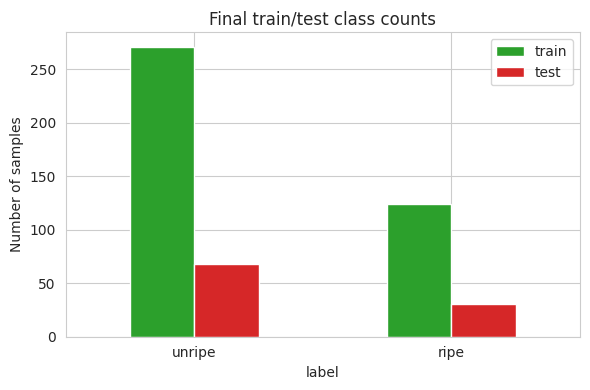

In [ ]:
n_train, n_test = len(train_balanced), len(test_df)
n_total = n_train + n_test

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total samples (train + test): {n_total}")
print(f"  Train: {n_train} samples ({n_train/n_total:.1%})")
print(f"  Test:  {n_test} samples ({n_test/n_total:.1%})")
print()
print("Train set class breakdown (natural distribution, NOT balanced):")
print(train_balanced["label"].value_counts().to_string())
print()
print("Test set class breakdown (untouched, reflects real-world imbalance):")
print(test_df["label"].value_counts().to_string())
print()
print(f"Number of features: {len(feature_cols)}")
print("=" * 60)

summary_counts = pd.DataFrame({
    "train": train_balanced["label"].value_counts(),
    "test": test_df["label"].value_counts(),
}).fillna(0).astype(int)

summary_counts.plot(kind="bar", color=[PALETTE.get(c, "gray") for c in summary_counts.index], figsize=(6, 4))
plt.title("Final train/test class counts")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Save outputs (CSV only -- no audio files exported)

In [ ]:
train_balanced.to_csv(os.path.join(OUT_DIR, "train_features_no_undersample.csv"), index=False)
test_df.to_csv(os.path.join(OUT_DIR, "test_features_no_undersample.csv"), index=False)
print(f"Saved train_features_no_undersample.csv ({len(train_balanced)} rows) and "
      f"test_features_no_undersample.csv ({len(test_df)} rows) to {OUT_DIR}")


Saved train_features_no_undersample.csv (395 rows) and test_features_no_undersample.csv (99 rows) to /content/drive/MyDrive/Watermelon Data/z. csv
